# recreating WSJ graph 

https://www.wsj.com/economy/jobs/capital-labor-wealth-economy-2fcf6c2f


## recreation

In [1]:
import pandas as pd
import numpy as np
from plotnine import *

In [2]:
years = np.linspace(1980, 2025, 451)

profits_y = [
    6.86, 6.7, 6.58, 6.49, 6.34, 6.24, 6.21, 6.31, 6.39, 6.45, 6.57, 6.61, 6.6, 6.58, 6.6,
    6.64, 6.59, 6.5, 6.36, 6.16, 6.03, 5.92, 5.82, 5.8, 5.83, 5.83, 5.78, 5.72, 5.7, 5.76,
    5.86, 6.01, 6.15, 6.3, 6.45, 6.59, 6.71, 6.81, 6.95, 7.07, 7.12, 7.19, 7.24, 7.18, 7.12,
    7.07, 7.02, 7.02, 7.02, 7.04, 7.04, 7.03, 7.02, 7.05, 7.09, 7.1, 7.03, 6.93, 6.81, 6.67,
    6.52, 6.39, 6.28, 6.19, 6.1, 6.04, 5.99, 5.94, 5.95, 6.01, 6.11, 6.2, 6.3, 6.42, 6.54,
    6.62, 6.66, 6.63, 6.6, 6.55, 6.54, 6.53, 6.53, 6.53, 6.55, 6.58, 6.61, 6.6, 6.57, 6.53,
    6.45, 6.35, 6.27, 6.2, 6.13, 6.04, 5.98, 5.93, 5.85, 5.84, 5.86, 5.9, 5.89, 5.84, 5.78,
    5.7, 5.64, 5.67, 5.72, 5.78, 5.87, 5.95, 6.0, 6.0, 5.99, 5.98, 5.96, 5.99, 6.03, 6.06,
    6.12, 6.15, 6.14, 6.12, 6.12, 6.13, 6.16, 6.18, 6.16, 6.18, 6.22, 6.26, 6.35, 6.46, 6.63,
    6.72, 6.81, 6.9, 7.01, 7.09, 7.12, 7.2, 7.27, 7.34, 7.43, 7.51, 7.56, 7.58, 7.57, 7.54,
    7.59, 7.66, 7.76, 7.81, 7.87, 7.94, 7.97, 8.01, 8.05, 8.1, 8.14, 8.18, 8.18, 8.17, 8.16,
    8.16, 8.2, 8.25, 8.28, 8.34, 8.41, 8.49, 8.53, 8.55, 8.54, 8.43, 8.27, 8.12, 7.99, 7.86,
    7.68, 7.62, 7.6, 7.56, 7.52, 7.49, 7.45, 7.44, 7.46, 7.49, 7.46, 7.39, 7.3, 7.21, 7.12,
    7.03, 6.95, 6.86, 6.77, 6.67, 6.57, 6.48, 6.37, 6.24, 6.11, 6.02, 5.92, 5.82, 5.78, 5.77,
    5.78, 5.77, 5.73, 5.66, 5.64, 5.71, 5.88, 5.98, 6.13, 6.37, 6.52, 6.65, 6.77, 6.88, 6.96,
    7.02, 7.13, 7.23, 7.3, 7.36, 7.43, 7.5, 7.58, 7.67, 7.79, 7.94, 8.05, 8.13, 8.28, 8.4,
    8.5, 8.55, 8.6, 8.65, 8.69, 8.77, 8.87, 8.91, 8.99, 9.06, 9.06, 9.09, 9.14, 9.23, 9.31,
    9.39, 9.51, 9.57, 9.59, 9.59, 9.62, 9.63, 9.55, 9.41, 9.25, 9.04, 8.89, 8.75, 8.59, 8.44,
    8.3, 8.16, 7.96, 7.73, 7.48, 7.3, 7.14, 6.97, 6.85, 6.73, 6.61, 6.29, 6.01, 5.87, 5.8,
    5.79, 5.87, 6.21, 6.56, 6.88, 7.06, 7.24, 7.47, 7.67, 7.85, 8.0, 8.09, 8.19, 8.31, 8.47,
    8.58, 8.62, 8.79, 8.78, 8.62, 8.55, 8.44, 8.32, 8.36, 8.45, 8.59, 8.75, 8.86, 8.94, 9.09,
    9.22, 9.33, 9.34, 9.34, 9.32, 9.28, 9.23, 9.19, 9.16, 9.16, 9.17, 9.17, 9.15, 9.12, 9.11,
    9.12, 9.13, 9.15, 9.1, 9.04, 9.02, 9.09, 9.19, 9.26, 9.39, 9.51, 9.54, 9.52, 9.49, 9.44,
    9.38, 9.3, 9.21, 9.12, 9.01, 8.87, 8.73, 8.61, 8.52, 8.52, 8.56, 8.63, 8.62, 8.58, 8.54,
    8.49, 8.46, 8.43, 8.38, 8.35, 8.32, 8.3, 8.28, 8.25, 8.22, 8.2, 8.18, 8.17, 8.17, 8.18,
    8.23, 8.26, 8.29, 8.34, 8.37, 8.38, 8.38, 8.36, 8.31, 8.3, 8.28, 8.27, 8.32, 8.36, 8.41,
    8.45, 8.38, 8.23, 8.1, 7.99, 7.92, 8.11, 8.48, 8.88, 9.0, 9.21, 9.4, 9.31, 9.39, 9.59,
    9.93, 10.18, 10.4, 10.57, 10.58, 10.51, 10.41, 10.29, 10.19, 10.15, 10.15, 10.17, 10.22, 10.27, 10.3,
    10.24, 10.22, 10.21, 10.22, 10.25, 10.27, 10.27, 10.3, 10.34, 10.41, 10.49, 10.54, 10.54, 10.52, 10.5,
    10.45, 10.47, 10.49, 10.49, 10.49, 10.5, 10.53, 10.52, 10.51, 10.49, 10.45, 10.45, 10.49, 10.52, 10.56,
    10.6
]

labor_y = [
    57.2, 57.28, 57.33, 57.35, 57.29, 57.17, 57.0, 56.81, 56.64, 56.49, 56.36, 56.27, 56.22, 56.12, 56.05,
    56.0, 55.95, 55.96, 56.05, 56.17, 56.26, 56.32, 56.3, 56.27, 56.21, 56.19, 56.19, 56.2, 56.18, 56.15,
    56.1, 56.04, 55.97, 55.9, 55.84, 55.78, 55.73, 55.62, 55.51, 55.41, 55.34, 55.26, 55.16, 55.15, 55.15,
    55.15, 55.16, 55.17, 55.16, 55.17, 55.19, 55.21, 55.24, 55.28, 55.34, 55.42, 55.49, 55.52, 55.61, 55.7,
    55.78, 55.83, 55.89, 55.97, 56.06, 56.15, 56.23, 56.28, 56.32, 56.34, 56.3, 56.25, 56.19, 56.11, 56.03,
    55.99, 55.99, 56.0, 56.01, 56.0, 55.98, 55.99, 55.98, 55.95, 55.92, 55.87, 55.83, 55.78, 55.74, 55.72,
    55.72, 55.74, 55.78, 55.84, 55.93, 56.02, 56.07, 56.14, 56.21, 56.27, 56.3, 56.33, 56.39, 56.43, 56.46,
    56.49, 56.47, 56.43, 56.4, 56.36, 56.32, 56.31, 56.33, 56.37, 56.42, 56.47, 56.52, 56.56, 56.61, 56.66,
    56.69, 56.72, 56.75, 56.77, 56.76, 56.74, 56.71, 56.68, 56.65, 56.63, 56.6, 56.58, 56.54, 56.47, 56.37,
    56.31, 56.22, 56.11, 56.0, 55.93, 55.88, 55.81, 55.76, 55.72, 55.64, 55.58, 55.53, 55.51, 55.5, 55.51,
    55.46, 55.41, 55.35, 55.31, 55.26, 55.18, 55.12, 55.07, 55.04, 54.99, 54.94, 54.91, 54.91, 54.91, 54.9,
    54.88, 54.85, 54.83, 54.81, 54.81, 54.8, 54.76, 54.73, 54.72, 54.77, 54.84, 54.96, 55.04, 55.12, 55.2,
    55.26, 55.29, 55.28, 55.31, 55.34, 55.36, 55.4, 55.44, 55.47, 55.49, 55.52, 55.55, 55.6, 55.65, 55.72,
    55.82, 55.9, 55.97, 56.02, 56.05, 56.03, 56.03, 56.04, 56.07, 56.11, 56.15, 56.18, 56.15, 56.1, 56.06,
    56.02, 55.97, 55.93, 55.97, 56.01, 56.0, 55.95, 55.88, 55.78, 55.67, 55.57, 55.51, 55.42, 55.34, 55.28,
    55.21, 55.14, 55.1, 55.1, 55.12, 55.15, 55.15, 55.13, 55.12, 55.08, 55.02, 54.97, 54.91, 54.85, 54.77,
    54.76, 54.76, 54.75, 54.71, 54.64, 54.55, 54.45, 54.35, 54.25, 54.17, 54.09, 53.99, 53.89, 53.79, 53.78,
    53.69, 53.58, 53.49, 53.44, 53.41, 53.33, 53.32, 53.36, 53.49, 53.66, 53.86, 53.98, 54.1, 54.19, 54.18,
    54.23, 54.31, 54.42, 54.55, 54.69, 54.82, 54.9, 54.96, 54.97, 54.93, 54.87, 54.95, 55.04, 55.13, 55.09,
    55.05, 54.99, 54.8, 54.62, 54.47, 54.37, 54.24, 54.09, 53.9, 53.71, 53.52, 53.41, 53.31, 53.23, 53.16,
    53.11, 53.08, 53.0, 52.99, 53.03, 53.06, 53.08, 53.09, 53.07, 53.01, 52.91, 52.75, 52.64, 52.58, 52.46,
    52.35, 52.26, 52.27, 52.31, 52.39, 52.44, 52.51, 52.62, 52.69, 52.71, 52.67, 52.62, 52.57, 52.55, 52.53,
    52.51, 52.49, 52.51, 52.55, 52.62, 52.64, 52.62, 52.55, 52.45, 52.34, 52.22, 52.23, 52.29, 52.38, 52.48,
    52.58, 52.64, 52.74, 52.83, 52.88, 52.95, 53.01, 53.07, 53.11, 53.14, 53.16, 53.19, 53.22, 53.25, 53.27,
    53.29, 53.31, 53.32, 53.32, 53.3, 53.3, 53.31, 53.34, 53.38, 53.43, 53.47, 53.5, 53.52, 53.51, 53.47,
    53.44, 53.4, 53.37, 53.33, 53.29, 53.27, 53.26, 53.28, 53.31, 53.35, 53.38, 53.4, 53.41, 53.36, 53.33,
    53.33, 53.4, 53.53, 53.72, 54.0, 54.34, 54.68, 54.87, 54.89, 54.82, 54.59, 54.29, 53.97, 53.8, 53.67,
    53.56, 53.42, 53.32, 53.23, 53.13, 53.03, 52.93, 52.78, 52.61, 52.41, 52.23, 52.08, 51.97, 51.87, 51.85,
    51.88, 51.93, 51.94, 51.94, 51.96, 51.98, 52.01, 52.08, 52.14, 52.18, 52.13, 52.1, 52.08, 52.07, 52.08,
    52.11, 52.14, 52.17, 52.19, 52.21, 52.21, 52.2, 52.19, 52.17, 52.15, 52.11, 52.04, 51.96, 51.89, 51.82,
    51.77
]

dfProfits = pd.DataFrame({
    'Year': years,
    'Percent': profits_y,
})

dfLabor = pd.DataFrame({
    'Year': years,
    'Percent': labor_y,
})


In [3]:
p1 = (
    ggplot(dfProfits, aes(x='Year', y='Percent'))
    + geom_line()
    + scale_x_continuous(breaks=[1980, 1990, 2000, 2010, 2020], name="Year")
    + theme_minimal()
)
p2 = (
    ggplot(dfLabor, aes(x='Year', y='Percent'))
    + geom_line()
    + scale_x_continuous(breaks=[1980, 1990, 2000, 2010, 2020], name="Year")
    + theme_minimal()
)


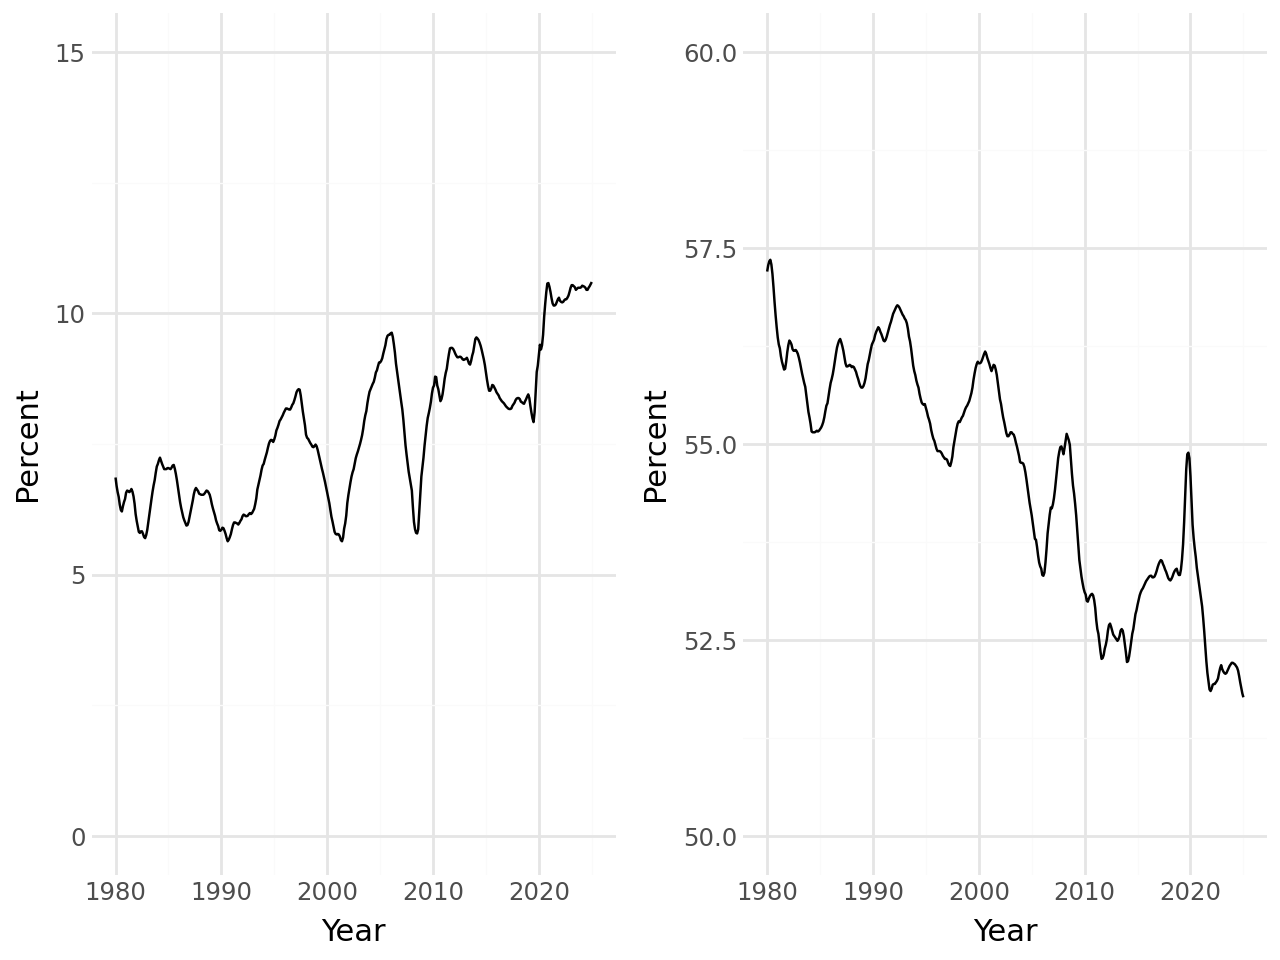

In [4]:
( p1 + scale_y_continuous(limits=(0,15)) 
 | p2 + scale_y_continuous(limits=(50,60))
 )

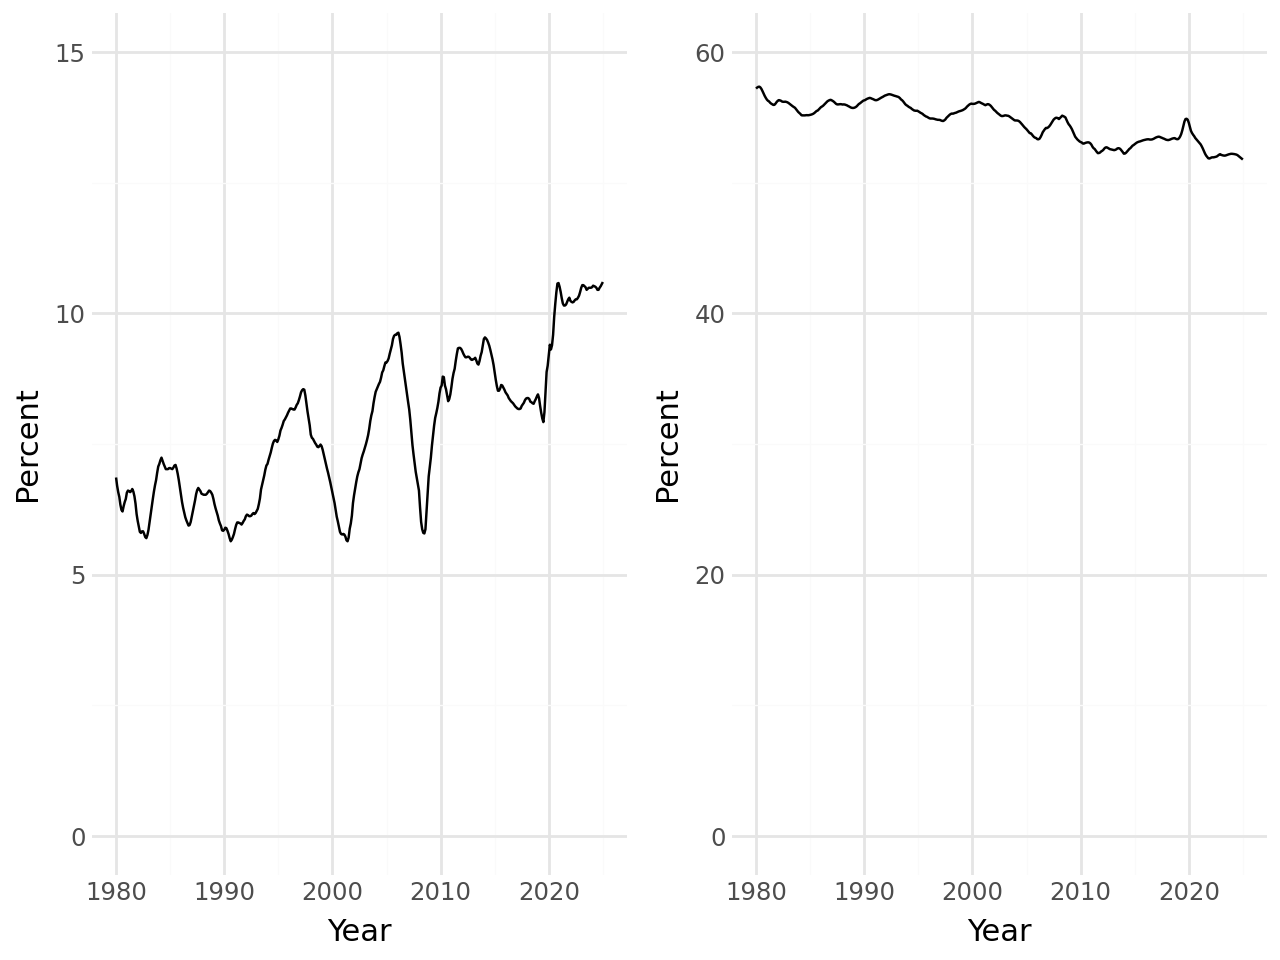

In [5]:
( p1 + scale_y_continuous(limits=(0,15)) 
 | p2 + scale_y_continuous(limits=(0,60))
 )


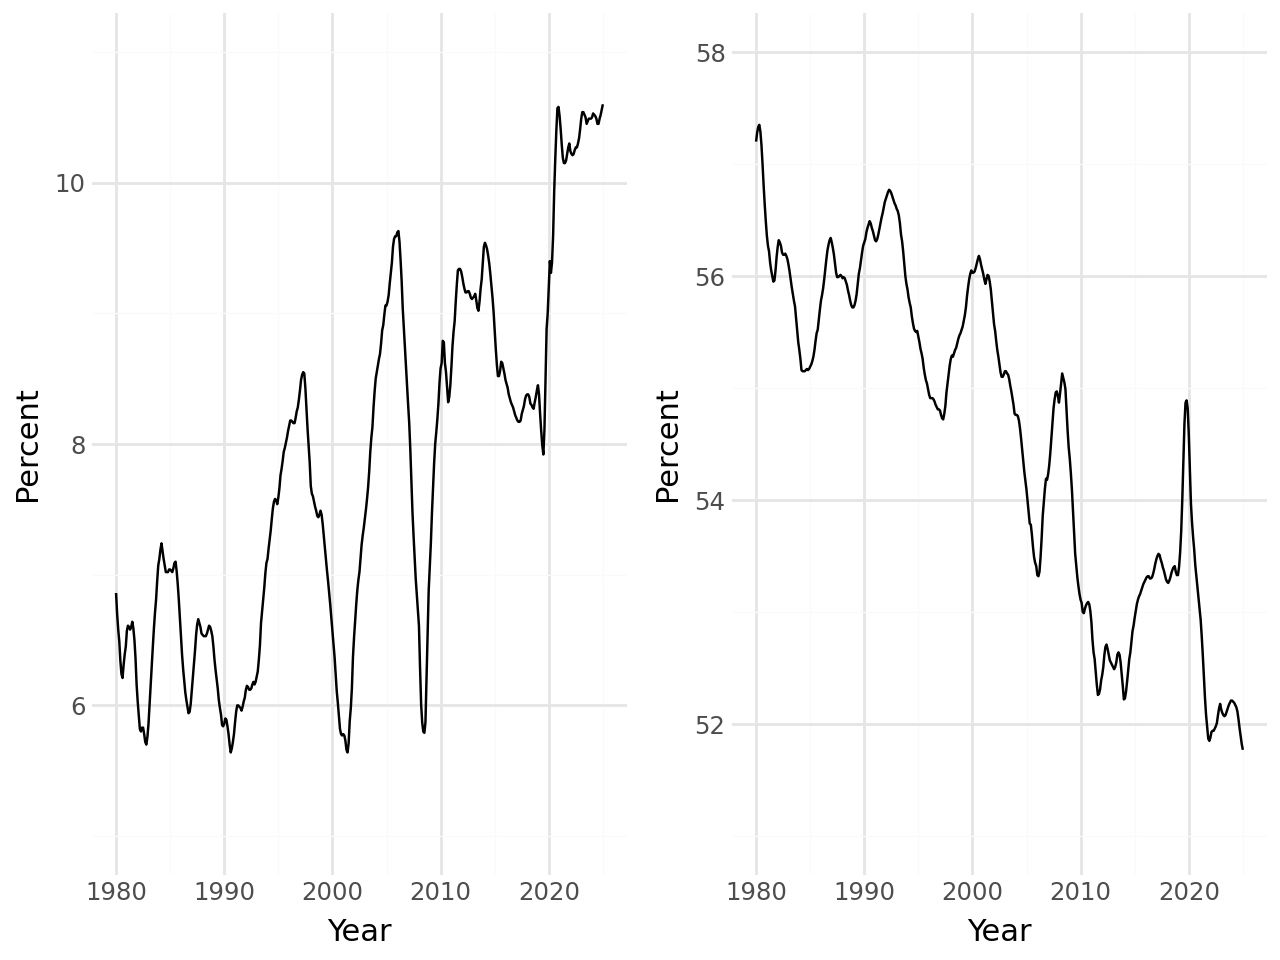

In [6]:
( p1 + scale_y_continuous(limits=(5,11)) 
 | p2 + scale_y_continuous(limits=(51,58))
 )

## original

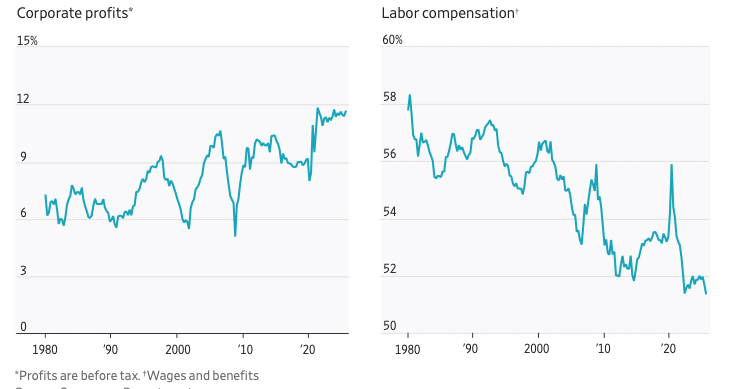